# SisFall — AFD-CNN Test Notebook (Repeat-Acc)

Loads the SisFall model checkpoint trained in `SisFall_train.ipynb` and evaluates it  
on `data/sisfall_test.csv` using the **repeat-acc** input variant.

**Prerequisites:** run `SisFall_train.ipynb` first to generate:
- `model/sisfall_model.ckpt`
- `data/sisfall_test.csv`

**Input layout:** each row in the CSV holds a `label` + 600 normalized ADXL345 values.  
At inference the 600 acc values are repeated to fill all 1200 model inputs:

| Image rows | Content |
|---|---|
| 0–9 (top half) | ADXL345 accelerometer (200 timesteps × R/G/B = ax/ay/az) |
| 10–19 (bottom half) | **Repeated** ADXL345 (identical copy) |

| Class label | Activity |
|---|---|
| 0 | **Fall** |
| 2 | Walk |
| 3 | Jog |
| 4 | Jump |
| 5 | Up-stairs |
| 6 | Down-stairs |
| 7 | Stand→Sit |
| 9 | Sit→Stand |

## 1. Setup

In [17]:
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

import importlib, cnn as cnn_module
importlib.reload(cnn_module)

CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NAMES = {
    0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
    5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand\u2192Sit', 9: 'Sit\u2192Stand'
}
CLASS_NUM = len(CLASS_LIST)

MODEL_PATH = 'model/sisfall_model.ckpt'
TEST_CSV   = 'data/sisfall_test.csv'

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.4.4


In [18]:
# Repeat-acc helpers — mirror the pattern from fd_cnn_demo - repeated accelerometer second half.ipynb

def rewrite_second_half(acc_600):
    """Expand 600 acc values to 1200 by repeating. Works on a single sample."""
    acc = np.array(acc_600, dtype=np.float32).reshape(-1)
    return np.concatenate([acc, acc]).astype(np.float32)


def rewrite_matrix_second_half(X_600):
    """Vectorized repeat-acc: (N, 600) → (N, 1200)."""
    X = np.array(X_600, dtype=np.float32)
    return np.hstack([X, X])


def to_image(acc_600):
    """Convert 600 acc values to the 20×20×3 repeat-acc image (0–1 range for display)."""
    repeated = rewrite_second_half(acc_600)          # (1200,)
    return repeated.reshape(20, 20, 3) / 255.0


print('Repeat-acc helpers ready.')

Repeat-acc helpers ready.


## 2. Load SisFall Test Data

In [19]:
test_df = pd.read_csv(TEST_CSV, index_col=False)
test_df = test_df[test_df['label'].isin(CLASS_LIST)].reset_index(drop=True)

# 600 acc values per row (columns 1..600)
X_test_600   = test_df.iloc[:, 1:601].values.astype(np.float32)   # (N, 600)
y_test_true  = test_df['label'].values.astype(int)

print(f'Test samples: {len(test_df)}')
print(f'Sensor value range: [{X_test_600.min():.1f}, {X_test_600.max():.1f}]')
print()
print('Class distribution:')
for lbl in CLASS_LIST:
    n = (y_test_true == lbl).sum()
    print(f'  label={lbl:2d}  {CLASS_NAMES[lbl]:12s}  {n:5d} samples')

Test samples: 2364
Sensor value range: [1.7, 201.6]

Class distribution:
  label= 0  Fall            300 samples
  label= 2  Walk            300 samples
  label= 3  Jog             300 samples
  label= 4  Jump            264 samples
  label= 5  Up-stairs       300 samples
  label= 6  Down-stairs     300 samples
  label= 7  Stand→Sit       300 samples
  label= 9  Sit→Stand       300 samples


## 3. Visualise Raw Sensor Signal

Each 600-value row encodes **200 timesteps × 3 axes** of the ADXL345 at 100 Hz (2 s window).  
The repeated second half is shown dashed — it is identical to the solid accelerometer trace.

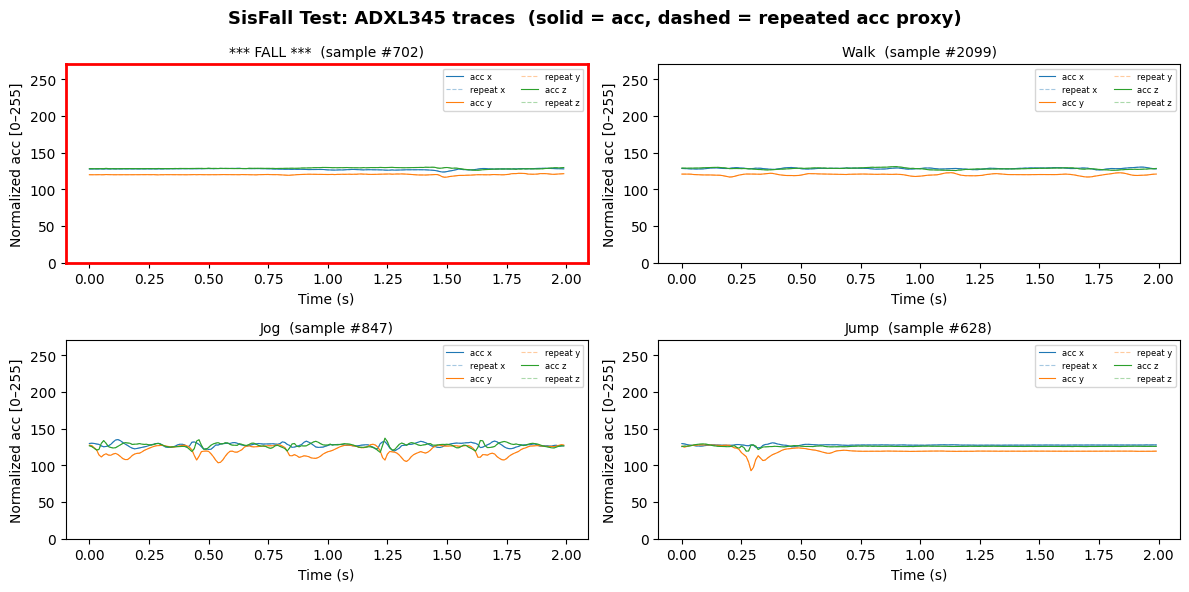

In [20]:
def plot_signals(acc_600, title, ax):
    """Plot acc (solid) and repeated second half (dashed) from a 600-element acc sample."""
    acc = acc_600.reshape(200, 3)
    t   = np.arange(200) / 100.0
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    for i, (name, color) in enumerate(zip(['x', 'y', 'z'], colors)):
        ax.plot(t, acc[:, i], color=color, linewidth=0.8, linestyle='-',  label=f'acc {name}')
        ax.plot(t, acc[:, i], color=color, linewidth=0.8, linestyle='--', alpha=0.4,
                label=f'repeat {name}')   # identical — shown for visual consistency with demo
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized acc [0\u2013255]')
    ax.legend(fontsize=6, ncol=2)
    ax.set_ylim(0, 270)


np.random.seed(42)
show_labels = [0, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, label in zip(axes.flat, show_labels):
    idxs = np.where(y_test_true == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    tag = '*** FALL ***' if label == 0 else CLASS_NAMES[label]
    plot_signals(X_test_600[sample_i], f'{tag}  (sample #{sample_i})', ax)
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle('SisFall Test: ADXL345 traces  (solid = acc, dashed = repeated acc proxy)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Sensor Data as 20×20 RGB Image

With repeat-acc the top and bottom halves of every image are identical.

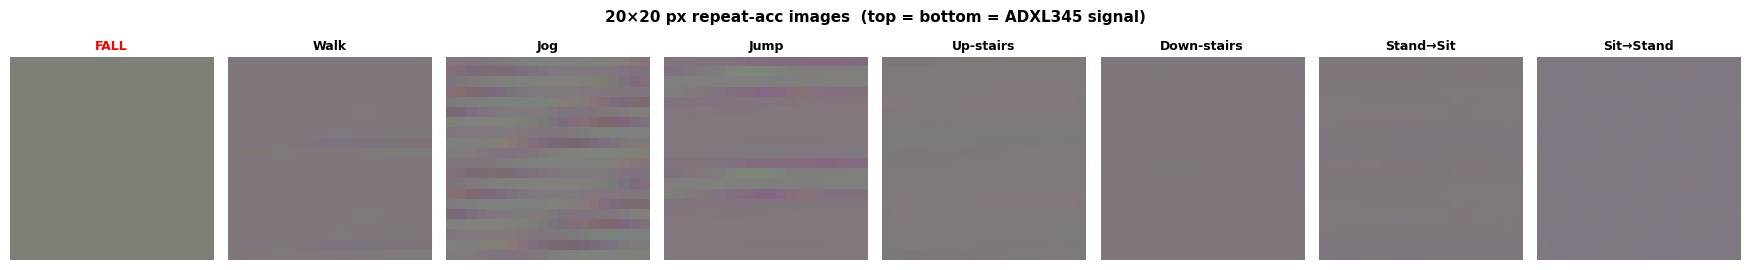

In [21]:
np.random.seed(7)
n = len(CLASS_LIST)

fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8))
for ax, label in zip(axes, CLASS_LIST):
    idxs = np.where(y_test_true == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    img = to_image(X_test_600[sample_i])
    ax.imshow(img)
    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    ax.set_title(tag, fontsize=9, color='red' if label == 0 else 'black', fontweight='bold')
    ax.axis('off')

fig.suptitle('20\u00d720 px repeat-acc images  (top = bottom = ADXL345 signal)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Load the SisFall Model

In [22]:
tf.reset_default_graph()
x_ph  = tf.placeholder(tf.float32, [None, 1200], name='input')
logits, keep_prob_ph = cnn_module.fall_net(x_ph)
probs_op = tf.nn.softmax(logits)

saver = tf.train.Saver()
sess  = tf.Session()
saver.restore(sess, MODEL_PATH)
print('Model restored from', MODEL_PATH)
print('Output shape (logits):', logits.shape)

Model restored from model/sisfall_model.ckpt
Output shape (logits): (?, 8)


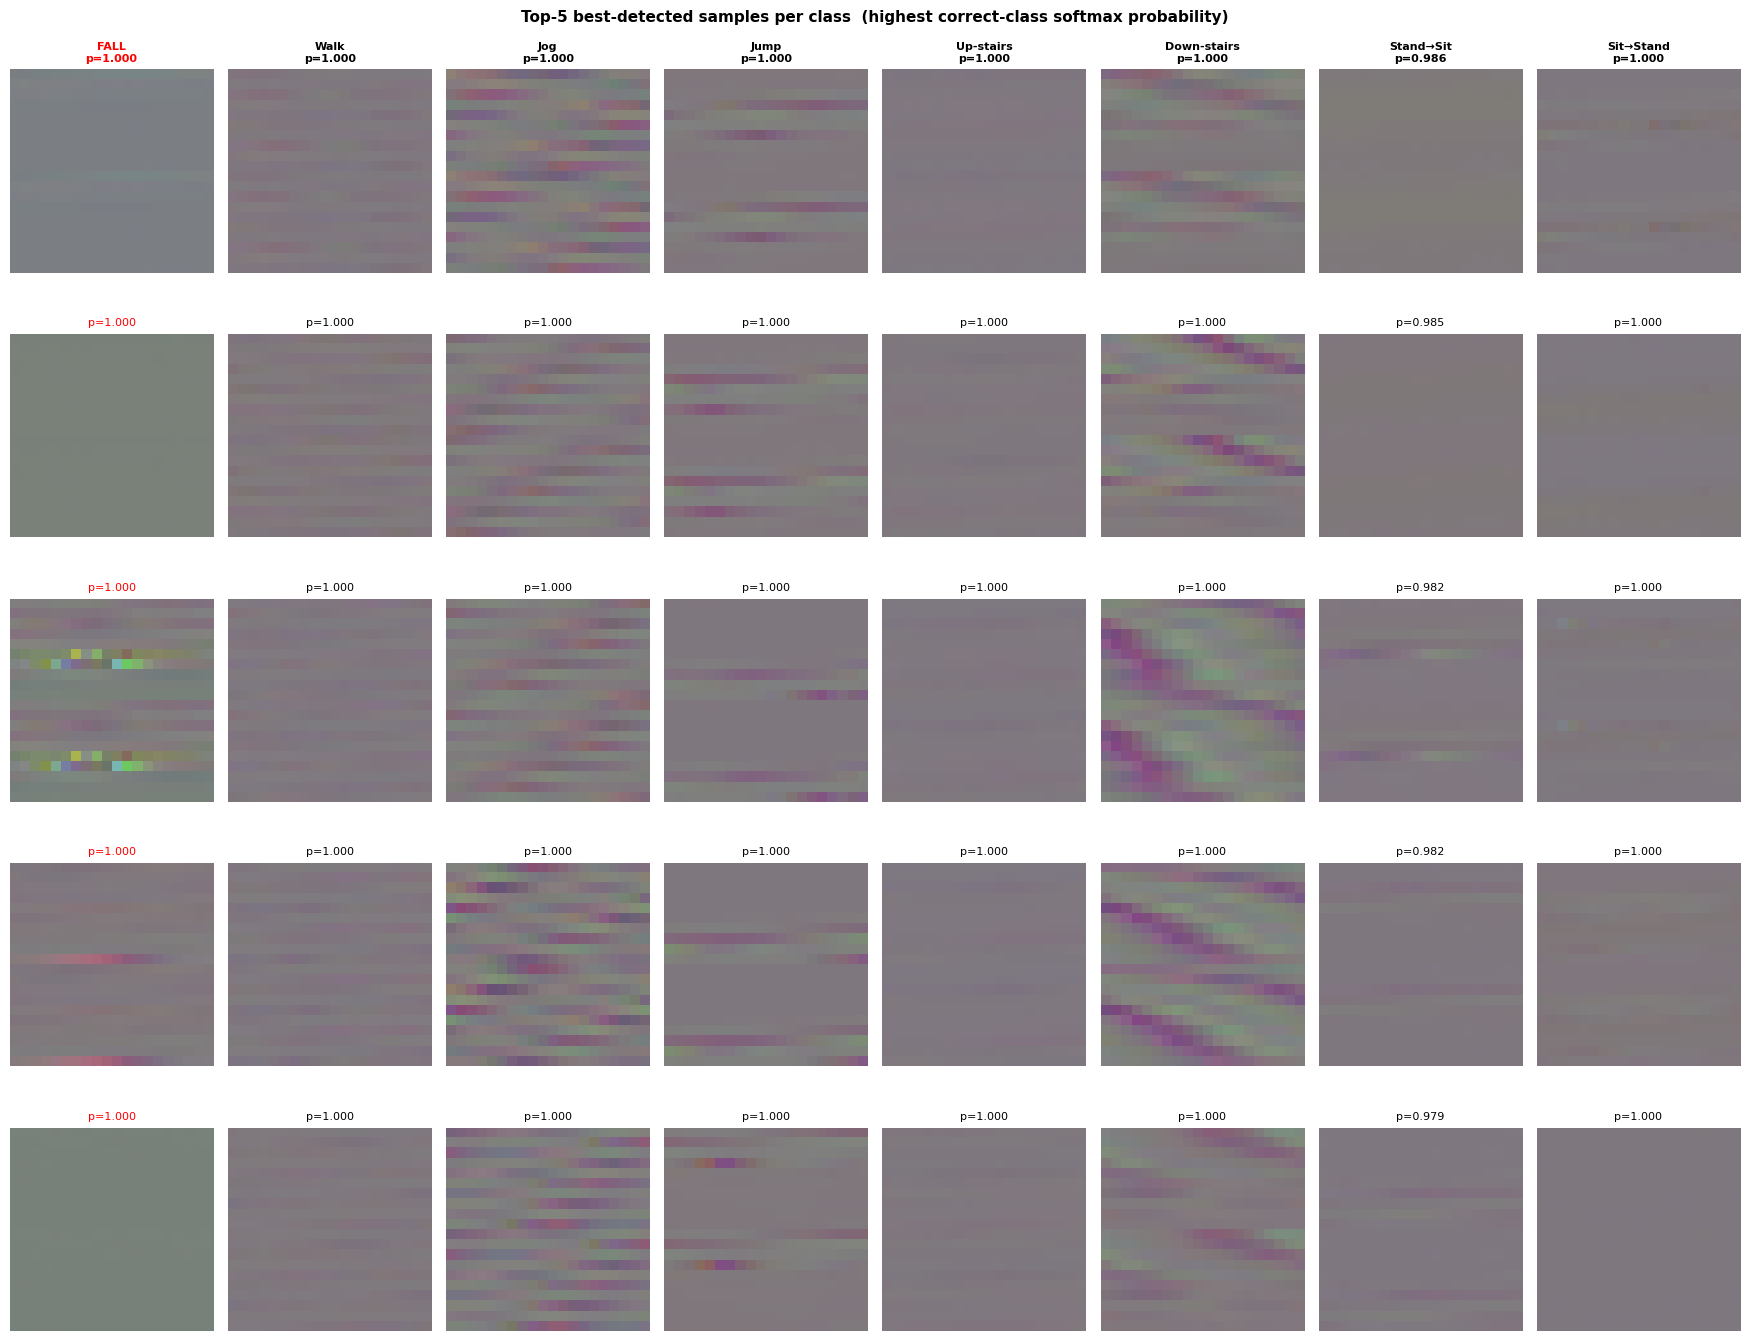

In [23]:
# Top-5 best-detected samples per class
TOP_N = 5

fig, axes = plt.subplots(TOP_N, n, figsize=(2.2 * n, 2.8 * TOP_N))

for col, label in enumerate(CLASS_LIST):
    idxs     = np.where(y_test_true == label)[0]
    X_class  = rewrite_matrix_second_half(X_test_600[idxs])   # (M, 1200)
    probs    = sess.run(probs_op, feed_dict={x_ph: X_class, keep_prob_ph: 1.0})

    correct_cls_idx = CLASS_LIST.index(label)
    top_local_idx   = np.argsort(probs[:, correct_cls_idx])[::-1][:TOP_N]

    for row, local_i in enumerate(top_local_idx):
        ax   = axes[row, col]
        img  = to_image(X_test_600[idxs[local_i]])
        ax.imshow(img)
        prob = probs[local_i, correct_cls_idx]
        tag  = 'FALL' if label == 0 else CLASS_NAMES[label]
        color = 'red' if label == 0 else 'black'
        if row == 0:
            ax.set_title(f'{tag}\np={prob:.3f}', fontsize=8, color=color, fontweight='bold')
        else:
            ax.set_title(f'p={prob:.3f}', fontsize=8, color=color)
        ax.axis('off')

fig.suptitle(f'Top-{TOP_N} best-detected samples per class  (highest correct-class softmax probability)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Inference Helper

In [24]:
def predict(samples_600):
    """
    Run inference on an (N, 600) acc array after applying repeat-acc.
    Returns:
        pred_labels  : array of integer class labels
        pred_names   : list of human-readable class names
        probabilities: (N, 8) softmax probabilities
    """
    X_in = rewrite_matrix_second_half(samples_600)   # (N, 1200)
    probs = sess.run(probs_op, feed_dict={x_ph: X_in, keep_prob_ph: 1.0})
    pred_idx    = np.argmax(probs, axis=1)
    pred_labels = [CLASS_LIST[i] for i in pred_idx]
    pred_names  = [CLASS_NAMES[l] for l in pred_labels]
    return pred_labels, pred_names, probs


print('predict() ready.')

predict() ready.


## 7. Positive Control — Fall Samples

Pick **20 random fall windows** from the test set and check that the model detects them.

In [25]:
np.random.seed(42)
N_SAMPLES = 20

fall_idxs = np.where(y_test_true == 0)[0]
chosen    = np.random.choice(fall_idxs, min(N_SAMPLES, len(fall_idxs)), replace=False)
fall_X    = X_test_600[chosen]

fall_pred_labels, fall_pred_names, fall_probs = predict(fall_X)

print('=== POSITIVE CONTROL (Fall) ===')
print(f'  Samples tested : {len(chosen)}')
correct = sum(1 for l in fall_pred_labels if l == 0)
print(f'  Correctly detected as Fall: {correct}/{len(chosen)}  '
      f'(sensitivity = {correct / len(chosen):.1%})')
print()
print(f'  {"#":>3}  {"True":10s}  {"Predicted":13s}  {"Fall prob":>9}  {"Max prob":>9}  OK?')
print('  ' + '-' * 60)
for i, (pred_lbl, pred_name, prob_row) in enumerate(
        zip(fall_pred_labels, fall_pred_names, fall_probs)):
    fall_prob = prob_row[CLASS_LIST.index(0)]
    max_prob  = prob_row.max()
    ok = '\u2713' if pred_lbl == 0 else '\u2717'
    print(f'  {i+1:>3}  {"Fall":10s}  {pred_name:13s}  {fall_prob:9.4f}  {max_prob:9.4f}  {ok}')

=== POSITIVE CONTROL (Fall) ===
  Samples tested : 20
  Correctly detected as Fall: 18/20  (sensitivity = 90.0%)

    #  True        Predicted      Fall prob   Max prob  OK?
  ------------------------------------------------------------
    1  Fall        Fall              0.8400     0.8400  ✓
    2  Fall        Fall              0.9118     0.9118  ✓
    3  Fall        Fall              0.7436     0.7436  ✓
    4  Fall        Fall              1.0000     1.0000  ✓
    5  Fall        Fall              1.0000     1.0000  ✓
    6  Fall        Fall              0.5139     0.5139  ✓
    7  Fall        Fall              0.9163     0.9163  ✓
    8  Fall        Fall              1.0000     1.0000  ✓
    9  Fall        Fall              0.6669     0.6669  ✓
   10  Fall        Fall              1.0000     1.0000  ✓
   11  Fall        Fall              1.0000     1.0000  ✓
   12  Fall        Jog               0.3124     0.6876  ✗
   13  Fall        Fall              1.0000     1.0000  ✓
   14  Fa

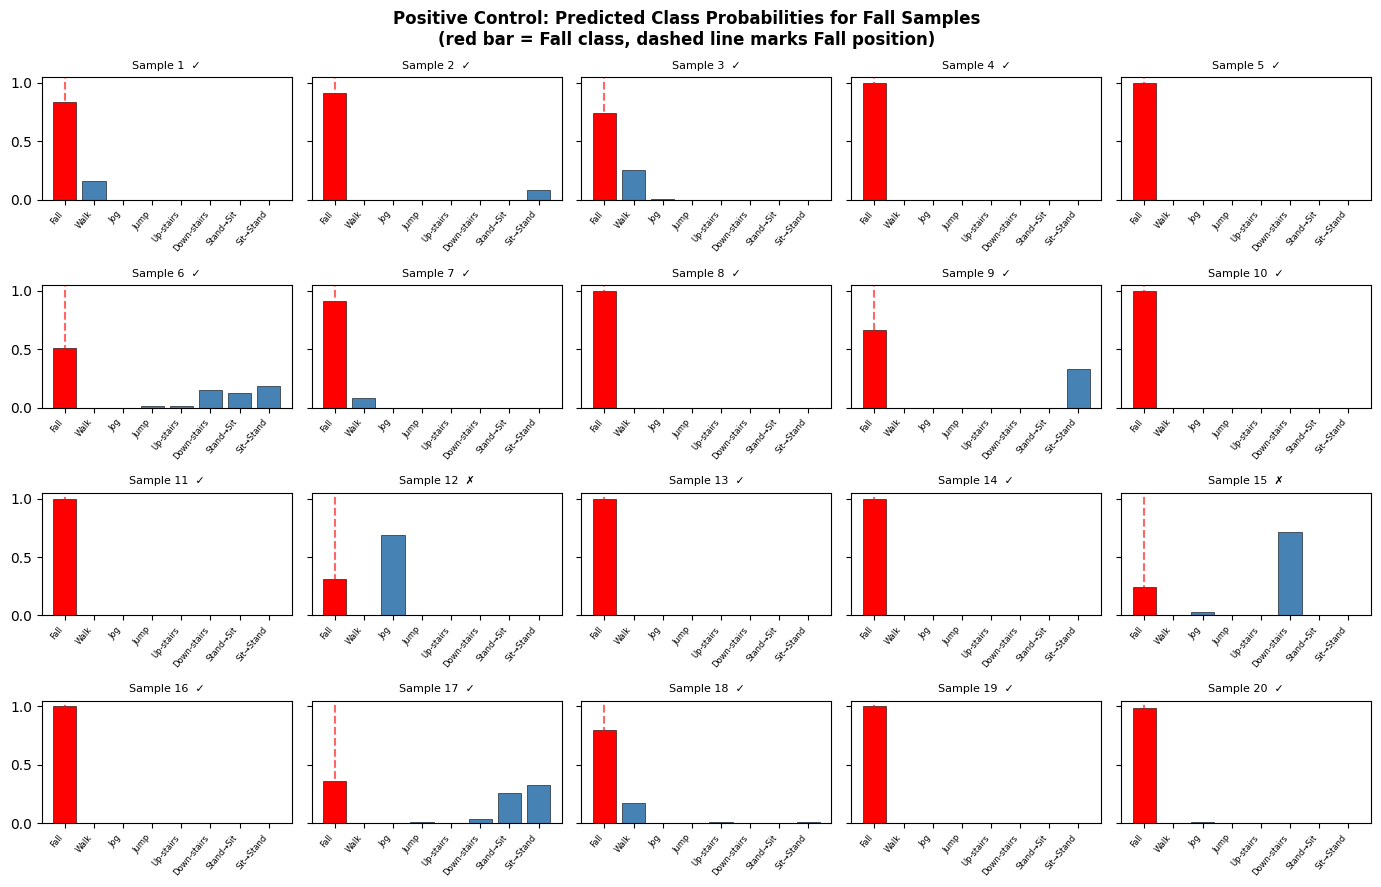

In [26]:
class_name_list = [CLASS_NAMES[l] for l in CLASS_LIST]
colors_bar = ['red' if l == 0 else 'steelblue' for l in CLASS_LIST]

fig, axes = plt.subplots(4, 5, figsize=(14, 9), sharey=True)
for i, ax in enumerate(axes.flat):
    if i >= len(chosen):
        ax.axis('off')
        continue
    ax.bar(range(8), fall_probs[i], color=colors_bar, edgecolor='black', linewidth=0.4)
    pred_ok = '\u2713' if fall_pred_labels[i] == 0 else '\u2717'
    ax.set_title(f'Sample {i+1}  {pred_ok}', fontsize=8)
    ax.set_xticks(range(8))
    ax.set_xticklabels(class_name_list, rotation=50, ha='right', fontsize=6)
    ax.set_ylim(0, 1.05)
    ax.axvline(x=0, color='red', linewidth=1.5, linestyle='--', alpha=0.6)

fig.suptitle('Positive Control: Predicted Class Probabilities for Fall Samples\n'
             '(red bar = Fall class, dashed line marks Fall position)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Negative Control — Non-Fall Activities

Take **5 samples from each of the 7 non-fall classes** and verify the model does not raise false alarms.

In [27]:
np.random.seed(42)
N_PER_CLASS = 5

neg_X_list, neg_true_list = [], []
for label in CLASS_LIST:
    if label == 0:
        continue
    idxs = np.where(y_test_true == label)[0]
    chosen_neg = np.random.choice(idxs, min(N_PER_CLASS, len(idxs)), replace=False)
    neg_X_list.append(X_test_600[chosen_neg])
    neg_true_list.extend([label] * len(chosen_neg))

neg_X    = np.vstack(neg_X_list)
neg_true = neg_true_list

neg_pred_labels, neg_pred_names, neg_probs = predict(neg_X)

print('=== NEGATIVE CONTROL (Non-Fall Activities) ===')
print(f'  Samples tested : {len(neg_true)}')
false_alarms = sum(1 for l in neg_pred_labels if l == 0)
print(f'  False alarms (predicted Fall): {false_alarms}/{len(neg_true)}  '
      f'(false-positive rate = {false_alarms / len(neg_true):.1%})')
print()
print(f'  {"#":>3}  {"True class":13s}  {"Predicted":13s}  {"Fall prob":>9}  OK?')
print('  ' + '-' * 57)
for i, (true_lbl, pred_lbl, pred_name, prob_row) in enumerate(
        zip(neg_true, neg_pred_labels, neg_pred_names, neg_probs)):
    fall_prob = prob_row[CLASS_LIST.index(0)]
    ok = '\u2713' if pred_lbl != 0 else '\u2717 FALSE ALARM'
    print(f'  {i+1:>3}  {CLASS_NAMES[true_lbl]:13s}  {pred_name:13s}  {fall_prob:9.4f}  {ok}')

=== NEGATIVE CONTROL (Non-Fall Activities) ===
  Samples tested : 35
  False alarms (predicted Fall): 0/35  (false-positive rate = 0.0%)

    #  True class     Predicted      Fall prob  OK?
  ---------------------------------------------------------
    1  Walk           Walk              0.0005  ✓
    2  Walk           Walk              0.0012  ✓
    3  Walk           Walk              0.0000  ✓
    4  Walk           Walk              0.0059  ✓
    5  Walk           Up-stairs         0.0063  ✓
    6  Jog            Jog               0.0000  ✓
    7  Jog            Jog               0.0000  ✓
    8  Jog            Jog               0.0000  ✓
    9  Jog            Jog               0.0000  ✓
   10  Jog            Jog               0.0000  ✓
   11  Jump           Jump              0.0000  ✓
   12  Jump           Jump              0.0000  ✓
   13  Jump           Jump              0.0000  ✓
   14  Jump           Jump              0.0000  ✓
   15  Jump           Jump              0.0000  ✓


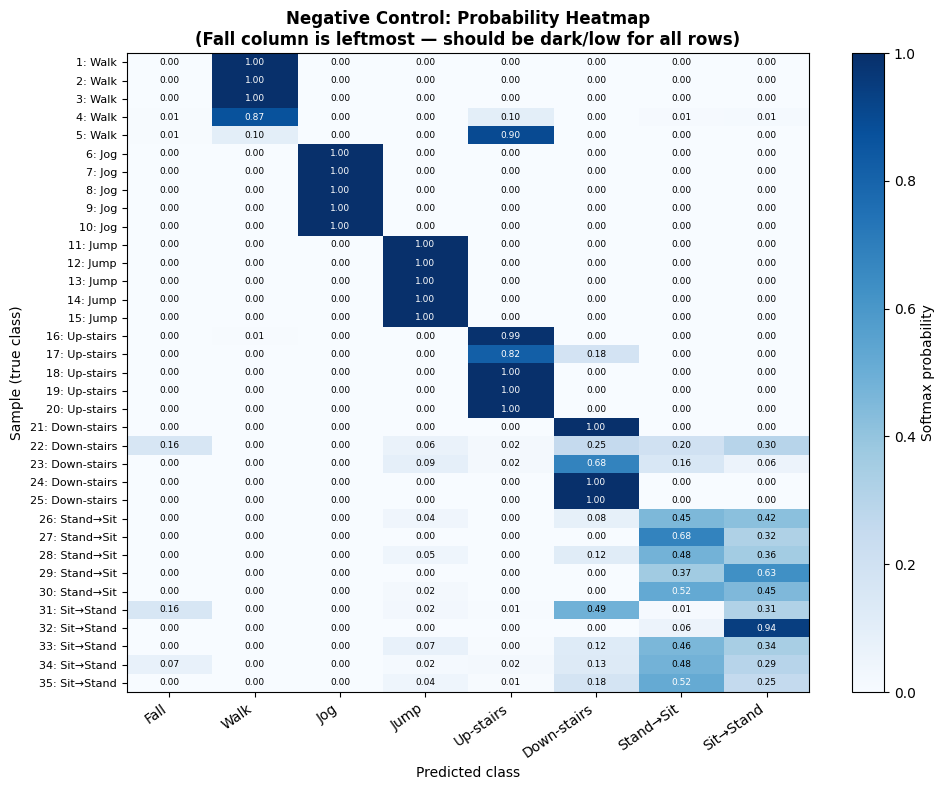

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(neg_probs, aspect='auto', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Softmax probability')

ax.set_xticks(range(8))
ax.set_xticklabels(class_name_list, rotation=35, ha='right')
ax.set_yticks(range(len(neg_true)))
ax.set_yticklabels([f'{i+1}: {CLASS_NAMES[l]}' for i, l in enumerate(neg_true)], fontsize=8)
ax.set_title('Negative Control: Probability Heatmap\n'
             '(Fall column is leftmost \u2014 should be dark/low for all rows)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted class')
ax.set_ylabel('Sample (true class)')

for row in range(len(neg_true)):
    for col in range(8):
        val   = neg_probs[row, col]
        color = 'white' if val > 0.5 else 'black'
        ax.text(col, row, f'{val:.2f}', ha='center', va='center', fontsize=6.5, color=color)

plt.tight_layout()
plt.show()

## 9. Full Test-Set Evaluation

In [29]:
test_pred_labels, _, test_probs = predict(X_test_600)
test_pred_labels = np.array(test_pred_labels)

overall_acc = np.mean(test_pred_labels == y_test_true)
print(f'Overall accuracy on sisfall_test.csv: {overall_acc:.4f}  ({overall_acc:.2%})')
print()
print(f'{"Class":>12s}  {"N":>5}  {"Accuracy":>9}  {"Sensitivity":>12}  {"Specificity":>12}')
print('-' * 60)

metrics = []
for lbl in CLASS_LIST:
    acc_val, sens, spec = cnn_module.evaluate(test_pred_labels, y_test_true, lbl)
    n_cls = int((y_test_true == lbl).sum())
    print(f'{CLASS_NAMES[lbl]:>12s}  {n_cls:>5}  {acc_val:>9.4f}  {sens:>12.4f}  {spec:>12.4f}')
    metrics.append({'class': CLASS_NAMES[lbl], 'label': lbl,
                    'n': n_cls, 'accuracy': acc_val,
                    'sensitivity': sens, 'specificity': spec})

metrics_df = pd.DataFrame(metrics)

Overall accuracy on sisfall_test.csv: 0.7885  (78.85%)

       Class      N   Accuracy   Sensitivity   Specificity
------------------------------------------------------------
        Fall    300     0.9691        0.8767        0.9826
        Walk    300     0.9920        0.9767        0.9942
         Jog    300     0.9945        0.9933        0.9947
        Jump    264     0.9480        0.7424        0.9738
   Up-stairs    300     0.9759        0.8667        0.9918
 Down-stairs    300     0.9234        0.6200        0.9675
   Stand→Sit    300     0.8828        0.7167        0.9070
   Sit→Stand    300     0.8913        0.5100        0.9467


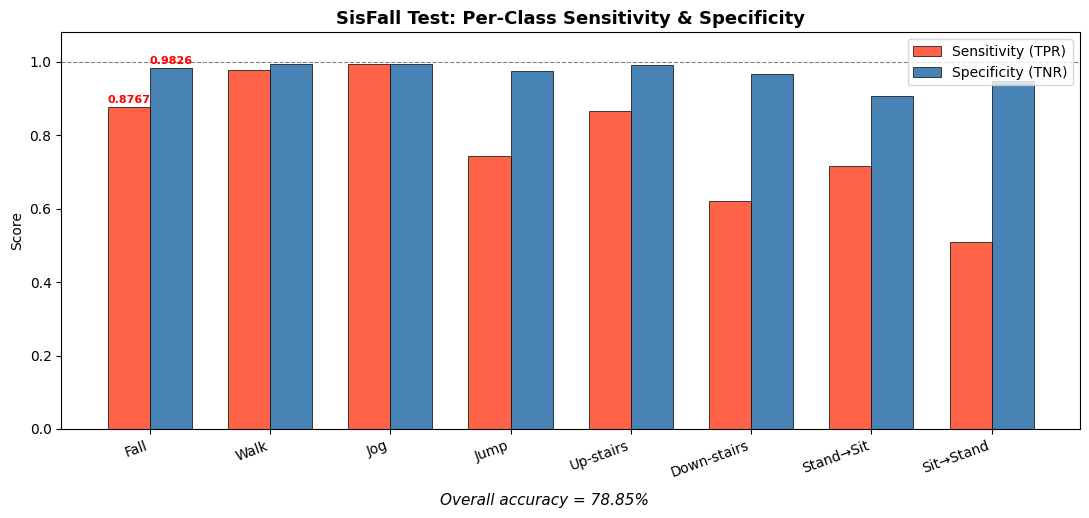

In [30]:
x_pos = np.arange(len(CLASS_LIST))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x_pos - width / 2, metrics_df['sensitivity'], width,
               label='Sensitivity (TPR)', color='tomato',    edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x_pos + width / 2, metrics_df['specificity'], width,
               label='Specificity (TNR)', color='steelblue', edgecolor='black', linewidth=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_df['class'], rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.set_title('SisFall Test: Per-Class Sensitivity & Specificity', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# Annotate Fall bars
for bar in [bars1[0], bars2[0]]:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=8, color='red', fontweight='bold')

fig.text(0.5, -0.02, f'Overall accuracy = {overall_acc:.2%}',
         ha='center', fontsize=11, style='italic')
plt.tight_layout()
plt.show()

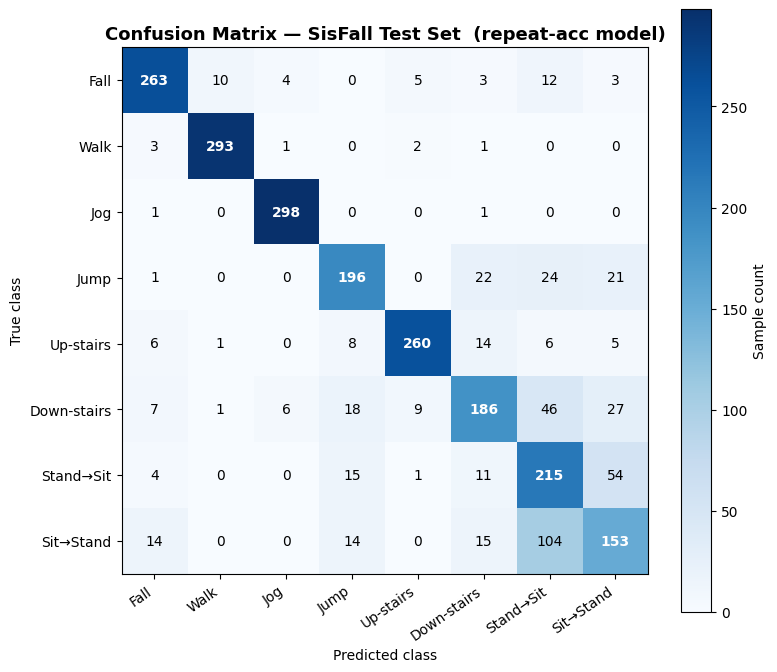

In [31]:
label_names = [CLASS_NAMES[l] for l in CLASS_LIST]
cm = confusion_matrix(y_test_true, test_pred_labels, labels=CLASS_LIST)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Sample count')

ax.set_xticks(range(len(CLASS_LIST)))
ax.set_yticks(range(len(CLASS_LIST)))
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Confusion Matrix \u2014 SisFall Test Set  (repeat-acc model)',
             fontsize=13, fontweight='bold')

for i in range(len(CLASS_LIST)):
    for j in range(len(CLASS_LIST)):
        val    = cm[i, j]
        color  = 'white' if val > cm.max() / 2 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, color=color, fontweight=weight)

plt.tight_layout()
plt.show()

## 10. Summary

In [32]:
pos_correct = sum(1 for l in fall_pred_labels if l == 0)
neg_correct = sum(1 for l in neg_pred_labels if l != 0)
n_neg       = len(neg_true)

fall_row  = metrics_df[metrics_df['label'] == 0].iloc[0]

print('=' * 64)
print('  EXPERIMENT SUMMARY  (SisFall repeat-acc model)')
print('=' * 64)
print()
print(f'  Model checkpoint : {MODEL_PATH}')
print(f'  Test CSV         : {TEST_CSV}')
print()
print(f'  \u2500\u2500 Sections 7 & 8: small hand-picked control sets \u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print(f'  Positive control  ({len(chosen)} random fall samples from test set):')
print(f'    {pos_correct}/{len(chosen)} correct  \u2192  {pos_correct / len(chosen):.1%} sensitivity')
print()
print(f'  Negative control  ({n_neg} random non-fall samples, {N_PER_CLASS} per class):')
print(f'    {neg_correct}/{n_neg} correct  \u2192  {neg_correct / n_neg:.1%} specificity  '
      f'({n_neg - neg_correct} false alarm(s))')
print()
print(f'  \u2500\u2500 Section 9: full test set ({len(y_test_true)} samples) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print(f'  Overall accuracy : {overall_acc:.2%}')
print(f'  Fall class       : {fall_row["n"]} samples  |  '
      f'sensitivity {fall_row["sensitivity"]:.4f}  |  specificity {fall_row["specificity"]:.4f}')
print('=' * 64)

sess.close()
print('Session closed.')

  EXPERIMENT SUMMARY  (SisFall repeat-acc model)

  Model checkpoint : model/sisfall_model.ckpt
  Test CSV         : data/sisfall_test.csv

  ── Sections 7 & 8: small hand-picked control sets ───────
  Positive control  (20 random fall samples from test set):
    18/20 correct  →  90.0% sensitivity

  Negative control  (35 random non-fall samples, 5 per class):
    35/35 correct  →  100.0% specificity  (0 false alarm(s))

  ── Section 9: full test set (2364 samples) ────────────
  Overall accuracy : 78.85%
  Fall class       : 300 samples  |  sensitivity 0.8767  |  specificity 0.9826
Session closed.
